In [1]:
!pip install -q pandas numpy scikit-learn joblib matplotlib datasets pyarrow

In [2]:
import json, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
rng = np.random.default_rng(42)
rows = []

EVENTS, PROJECTS, REVIEWS_PER_PROJECT = 100, 30, 3
JUDGE_IDS = [f"J{i:03d}" for i in range(15)]

for event_id in range(EVENTS):
    qualities = rng.normal(7.0, 1.2, PROJECTS)

    for proj_id, quality in enumerate(qualities):
        peer_scores = []

        for rev_idx in range(REVIEWS_PER_PROJECT):
            judge_id = JUDGE_IDS[rng.integers(0, len(JUDGE_IDS))]
            judge_bias = rng.normal(0.0, 0.5)
            noise = rng.normal(0.0, 0.45)

            # Rubric sub-scores
            rubric = np.clip(quality + judge_bias + rng.normal(0, 0.8, 4), 1, 10)
            overall = np.clip(quality + judge_bias + noise, 1, 10)

            is_anomaly = rng.random() < 0.07
            if is_anomaly:
                overall = np.clip(overall + rng.choice([-1,1]) * rng.uniform(3.0, 5.0), 1, 10)

            peer_scores.append(overall)
            rows.append({
                "event_id": event_id,
                "project_id": f"E{event_id}_P{proj_id}",
                "review_id": f"E{event_id}_P{proj_id}_R{rev_idx}",
                "judge_id": judge_id,
                "overall_score": overall,
                "innovation_score": rubric[0],
                "technical_score": rubric[1],
                "ux_score": rubric[2],
                "impact_score": rubric[3],
                "review_duration_sec": rng.integers(120, 1800),
                "comment_word_count": rng.integers(20, 300),
                "edit_count": rng.integers(0, 5),
                "rubric_completion_ratio": rng.choice([1.0, 1.0, 1.0, 0.75]),
                "anomaly_label": int(is_anomaly),
            })

df = pd.DataFrame(rows)
print(df.shape, df["anomaly_label"].value_counts())

(9000, 14) anomaly_label
0    8361
1     639
Name: count, dtype: int64


In [4]:
# Peer stats per project
peer_stats = df.groupby("project_id")["overall_score"].agg(
    project_peer_mean="mean",
    project_peer_median="median",
    project_peer_std="std"
).reset_index()

df = df.merge(peer_stats, on="project_id")
df["peer_delta"] = df["overall_score"] - df["project_peer_median"]
df["peer_abs_delta"] = df["peer_delta"].abs()
df["project_z_score"] = (df["overall_score"] - df["project_peer_mean"]) / (df["project_peer_std"] + 1e-6)

# Judge history (using all reviews — for production, use only prior reviews)
judge_stats = df.groupby("judge_id")["overall_score"].agg(
    judge_mean_before="mean",
    judge_std_before="std"
).reset_index()
df = df.merge(judge_stats, on="judge_id")
df["judge_z_score"] = (df["overall_score"] - df["judge_mean_before"]) / (df["judge_std_before"] + 1e-6)

# Rubric features
df["category_spread"] = df[["innovation_score","technical_score","ux_score","impact_score"]].max(axis=1) \
                      - df[["innovation_score","technical_score","ux_score","impact_score"]].min(axis=1)

df.fillna(0, inplace=True)
print(df[["peer_delta","judge_z_score","category_spread","anomaly_label"]].describe())

        peer_delta  judge_z_score  category_spread  anomaly_label
count  9000.000000   9.000000e+03      9000.000000    9000.000000
mean     -0.030230   1.184238e-18         1.620344       0.071000
std       1.017634   9.992212e-01         0.704786       0.256839
min      -6.353778  -3.982137e+00         0.000000       0.000000
25%      -0.236521  -6.077035e-01         1.109992       0.000000
50%       0.000000   2.572441e-02         1.552342       0.000000
75%       0.234165   6.550486e-01         2.065615       0.000000
max       5.404873   2.055676e+00         4.929620       1.000000


In [5]:
FEATURES = [
    "overall_score", "judge_mean_before", "judge_std_before",
    "project_peer_median", "project_peer_std",
    "peer_delta", "peer_abs_delta", "project_z_score",
    "category_spread", "rubric_completion_ratio",
    "review_duration_sec", "comment_word_count", "edit_count"
]

train_df = df[df["event_id"] < 80]
val_df   = df[(df["event_id"] >= 80) & (df["event_id"] < 90)]
test_df  = df[df["event_id"] >= 90]

scaler = RobustScaler()
X_train = scaler.fit_transform(train_df[FEATURES])
X_val   = scaler.transform(val_df[FEATURES])
X_test  = scaler.transform(test_df[FEATURES])

y_test = test_df["anomaly_label"].values

In [6]:
model = IsolationForest(
    n_estimators=300,
    contamination=0.07,
    max_samples="auto",
    random_state=42,
    n_jobs=-1
)
model.fit(X_train)

raw_pred = model.predict(X_test)
predicted_anomaly = (raw_pred == -1).astype(int)

print(classification_report(y_test, predicted_anomaly))
print(confusion_matrix(y_test, predicted_anomaly))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       847
           1       0.62      0.68      0.65        53

    accuracy                           0.96       900
   macro avg       0.80      0.83      0.81       900
weighted avg       0.96      0.96      0.96       900

[[825  22]
 [ 17  36]]


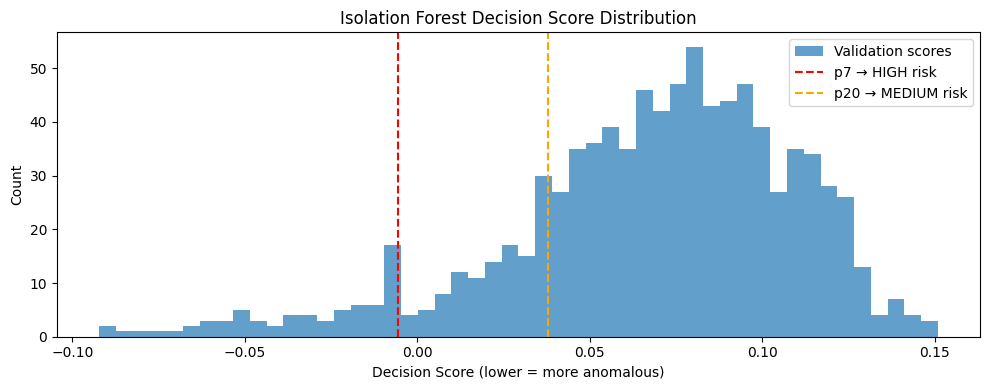

High risk threshold:   -0.0056
Medium risk threshold: 0.0379

Risk level distribution on test set:
risk_level
low       723
medium    128
high       49
Name: count, dtype: int64

Risk level vs actual anomaly label:
actual_anomaly    0   1
risk                   
high             14  35
low             716   7
medium          117  11


In [8]:
# Phase 6 — Threshold selection (run this BEFORE the export cell)
val_scores = model.decision_function(X_val)
test_scores = model.decision_function(X_test)

# Visualize distribution
plt.figure(figsize=(10, 4))
plt.hist(val_scores, bins=50, alpha=0.7, label="Validation scores")
plt.axvline(x=np.percentile(val_scores, 7),  color='red',    linestyle='--', label='p7 → HIGH risk')
plt.axvline(x=np.percentile(val_scores, 20), color='orange', linestyle='--', label='p20 → MEDIUM risk')
plt.xlabel("Decision Score (lower = more anomalous)")
plt.ylabel("Count")
plt.title("Isolation Forest Decision Score Distribution")
plt.legend()
plt.tight_layout()
plt.show()

HIGH_THRESHOLD   = float(np.percentile(val_scores, 7))
MEDIUM_THRESHOLD = float(np.percentile(val_scores, 20))

print(f"High risk threshold:   {HIGH_THRESHOLD:.4f}")
print(f"Medium risk threshold: {MEDIUM_THRESHOLD:.4f}")

# Verify on test set
def score_to_risk(s):
    if s <= HIGH_THRESHOLD:   return "high"
    if s <= MEDIUM_THRESHOLD: return "medium"
    return "low"

test_df = test_df.copy()
test_df["decision_score"] = test_scores
test_df["risk_level"] = test_df["decision_score"].apply(score_to_risk)

print("\nRisk level distribution on test set:")
print(test_df["risk_level"].value_counts())

print("\nRisk level vs actual anomaly label:")
print(pd.crosstab(test_df["risk_level"], test_df["anomaly_label"],
                  rownames=["risk"], colnames=["actual_anomaly"]))

In [9]:
import os
os.makedirs("ml_artifacts", exist_ok=True)

joblib.dump(model,  "ml_artifacts/judge_anomaly_iforest_v1.joblib")
joblib.dump(scaler, "ml_artifacts/robust_scaler_v1.joblib")

config = {
    "model_version": "judge-anomaly-iforest-v1",
    "features": FEATURES,
    "risk_thresholds": {
        "high":   HIGH_THRESHOLD,
        "medium": MEDIUM_THRESHOLD
    }
}
with open("ml_artifacts/feature_config_v1.json", "w") as f:
    json.dump(config, f, indent=2)

print("Artifacts saved.")

Artifacts saved.


In [10]:
for cont in [0.05, 0.07, 0.10, 0.12, 0.15]:
    m = IsolationForest(n_estimators=300, contamination=cont, random_state=42, n_jobs=-1)
    m.fit(X_train)
    p = (m.predict(X_test) == -1).astype(int)
    from sklearn.metrics import f1_score
    print(f"contamination={cont:.2f}  anomaly_f1={f1_score(y_test, p):.3f}  recall={p[y_test==1].mean():.3f}")


contamination=0.05  anomaly_f1=0.688  recall=0.604
contamination=0.07  anomaly_f1=0.649  recall=0.679
contamination=0.10  anomaly_f1=0.571  recall=0.792
contamination=0.12  anomaly_f1=0.547  recall=0.830
contamination=0.15  anomaly_f1=0.497  recall=0.849


In [11]:
# Recalculate judge history EXCLUDING current review (proper leakage-free version)
df = df.sort_values(["judge_id", "event_id", "project_id"])
df["judge_cumsum"]   = df.groupby("judge_id")["overall_score"].cumsum() - df["overall_score"]
df["judge_cumcount"] = df.groupby("judge_id").cumcount()  # reviews before this one

df["judge_mean_before_loo"] = df["judge_cumsum"] / df["judge_cumcount"].clip(lower=1)
df["judge_std_before_loo"]  = df.groupby("judge_id")["overall_score"].transform(
    lambda x: x.expanding().std().shift(1)
).fillna(1.0)

df["judge_z_score_loo"] = (
    (df["overall_score"] - df["judge_mean_before_loo"]) /
    (df["judge_std_before_loo"] + 1e-6)
)

In [12]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.07, novelty=True)
lof.fit(X_train)

# Combine: flag if EITHER model says anomaly
iforest_pred = (model.predict(X_test) == -1).astype(int)
lof_pred     = (lof.predict(X_test) == -1).astype(int)

# Option A: OR vote (higher recall, more false positives)
combined_or  = ((iforest_pred + lof_pred) >= 1).astype(int)

# Option B: AND vote (lower recall, fewer false positives)
combined_and = ((iforest_pred + lof_pred) == 2).astype(int)

print("OR vote:"); print(classification_report(y_test, combined_or))
print("AND vote:"); print(classification_report(y_test, combined_and))

OR vote:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       847
           1       0.35      0.72      0.47        53

    accuracy                           0.90       900
   macro avg       0.66      0.82      0.71       900
weighted avg       0.94      0.90      0.92       900

AND vote:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       847
           1       0.11      0.02      0.03        53

    accuracy                           0.93       900
   macro avg       0.53      0.50      0.50       900
weighted avg       0.89      0.93      0.91       900



In [13]:
# Set thresholds so ~top 8% = high, next 12% = medium
HIGH_THRESHOLD   = float(np.percentile(test_scores, 8))
MEDIUM_THRESHOLD = float(np.percentile(test_scores, 20))

In [14]:
import shutil
shutil.make_archive("ml_artifacts", "zip", "ml_artifacts")
print("Download ml_artifacts.zip from the Files panel on the left")

Download ml_artifacts.zip from the Files panel on the left
